In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DateGlobal_Tea_Price.xlsx to DateGlobal_Tea_Price (2).xlsx
Saving Tea_Export_Master_2008_2024.xlsx to Tea_Export_Master_2008_2024 (2).xlsx


In [ ]:
import pandas as pd

sl_df = pd.read_excel("Tea_Export_Master_2008_2024 (1).xlsx")
global_df = pd.read_excel("DateGlobal_Tea_Price.xlsx")

In [ ]:
sl_df.head()

,Year,Month,Export Quantity (kg),Export Price (LKR/kg),Exchange Rate (LKR/USD),Export Price (USD/kg)
0,2008,January,25100000,385.12,108.166957,3.560422
1,2008,February,23850000,398.40,107.845238,3.694183
2,2008,March,27200000,412.55,107.731905,3.829413
3,2008,April,21400000,425.30,107.803182,3.945153
4,2008,May,28500000,438.10,107.787273,4.064487


In [ ]:
global_df.head()

,Year,Month,Global_Tea_Price ($)
0,2008,January,2.377179
1,2008,February,2.396840
2,2008,March,2.262599
3,2008,April,2.487884
4,2008,May,2.483759


In [ ]:
sl_df.columns

Index(['Year', 'Month', 'Export Quantity (kg)', 'Export Price (LKR/kg)',
       'Exchange Rate (LKR/USD)', 'Export Price (USD/kg)'],
      dtype='object')

In [ ]:
global_df.columns

Index(['Year', 'Month', 'Global_Tea_Price ($)'], dtype='object')

In [ ]:
# Convert Month text → number (Sri Lanka dataset)
sl_df['Month_num'] = pd.to_datetime(sl_df['Month'], format='%B').dt.month

# Create time index (DO NOT store as column)
sl_df.index = pd.to_datetime(
    sl_df['Year'].astype(str) + '-' + sl_df['Month_num'].astype(str),
    format='%Y-%m'
)


# Convert Month text → number (Global dataset)
global_df['Month_num'] = pd.to_datetime(global_df['Month'], format='%B').dt.month

# Create time index
global_df.index = pd.to_datetime(
    global_df['Year'].astype(str) + '-' + global_df['Month_num'].astype(str),
    format='%Y-%m'
)

In [ ]:
sl_df.head()

,Year,Month,Export Quantity (kg),Export Price (LKR/kg),Exchange Rate (LKR/USD),Export Price (USD/kg),Month_num
2008-01-01,2008,January,25100000,385.12,108.166957,3.560422,1
2008-02-01,2008,February,23850000,398.40,107.845238,3.694183,2
2008-03-01,2008,March,27200000,412.55,107.731905,3.829413,3
2008-04-01,2008,April,21400000,425.30,107.803182,3.945153,4
2008-05-01,2008,May,28500000,438.10,107.787273,4.064487,5


In [ ]:
global_df.head()

,Year,Month,Global_Tea_Price ($),Month_num
2008-01-01,2008,January,2.377179,1
2008-02-01,2008,February,2.396840,2
2008-03-01,2008,March,2.262599,3
2008-04-01,2008,April,2.487884,4
2008-05-01,2008,May,2.483759,5


In [ ]:
sl_df = sl_df.drop(columns=['Month_num'])
global_df = global_df.drop(columns=['Month_num'])

In [ ]:
sl_df.head()

,Year,Month,Export Quantity (kg),Export Price (LKR/kg),Exchange Rate (LKR/USD),Export Price (USD/kg)
2008-01-01,2008,January,25100000,385.12,108.166957,3.560422
2008-02-01,2008,February,23850000,398.40,107.845238,3.694183
2008-03-01,2008,March,27200000,412.55,107.731905,3.829413
2008-04-01,2008,April,21400000,425.30,107.803182,3.945153
2008-05-01,2008,May,28500000,438.10,107.787273,4.064487


In [ ]:
global_df.head()

,Year,Month,Global_Tea_Price ($)
2008-01-01,2008,January,2.377179
2008-02-01,2008,February,2.396840
2008-03-01,2008,March,2.262599
2008-04-01,2008,April,2.487884
2008-05-01,2008,May,2.483759


In [ ]:
# Keep only the global price column
global_df = global_df[['Global_Tea_Price ($)']]

# Merge using the time index
df = sl_df.merge(global_df, left_index=True, right_index=True, how='left')

In [ ]:
df.head()

,Year,Month,Export Quantity (kg),Export Price (LKR/kg),Exchange Rate (LKR/USD),Export Price (USD/kg),Global_Tea_Price ($)
2008-01-01,2008,January,25100000,385.12,108.166957,3.560422,2.377179
2008-02-01,2008,February,23850000,398.40,107.845238,3.694183,2.396840
2008-03-01,2008,March,27200000,412.55,107.731905,3.829413,2.262599
2008-04-01,2008,April,21400000,425.30,107.803182,3.945153,2.487884
2008-05-01,2008,May,28500000,438.10,107.787273,4.064487,2.483759


In [ ]:
df.columns

Index(['Year', 'Month', 'Export Quantity (kg)', 'Export Price (LKR/kg)',
       'Exchange Rate (LKR/USD)', 'Export Price (USD/kg)',
       'Global_Tea_Price ($)'],
      dtype='object')

In [ ]:
import numpy as np

cols = [
    'Export Quantity (kg)',
    'Export Price (LKR/kg)',
    'Exchange Rate (LKR/USD)',
    'Export Price (USD/kg)',
    'Global_Tea_Price ($)'
]

for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('\n', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
df.isna().sum()

,0
Year,0
Month,0
Export Quantity (kg),0
Export Price (LKR/kg),0
Exchange Rate (LKR/USD),0
Export Price (USD/kg),0
Global_Tea_Price ($),0


In [ ]:
df = df.sort_index()
df[cols] = df[cols].ffill().bfill()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 204 entries, 2008-01-01 to 2024-12-01
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     204 non-null    int64  
 1   Month                    204 non-null    object 
 2   Export Quantity (kg)     204 non-null    float64
 3   Export Price (LKR/kg)    204 non-null    float64
 4   Exchange Rate (LKR/USD)  204 non-null    float64
 5   Export Price (USD/kg)    204 non-null    float64
 6   Global_Tea_Price ($)     204 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 12.8+ KB


In [ ]:
summary = df[
    [
        'Export Price (USD/kg)',
        'Export Quantity (kg)',
        'Global_Tea_Price ($)',
        'Exchange Rate (LKR/USD)'
    ]
].describe()

summary

,Export Price (USD/kg),Export Quantity (kg),Global_Tea_Price ($),Exchange Rate (LKR/USD)
count,204.000000,2.040000e+02,204.000000,204.000000
mean,4.566477,2.337206e+07,2.804162,175.381711
std,0.485323,3.637947e+06,0.265969,75.682849
min,3.233524,1.297400e+07,1.926013,107.627609
25%,4.274978,2.083405e+07,2.647841,126.485000
50%,4.505075,2.314007e+07,2.798314,147.656207
75%,4.853685,2.589974e+07,2.997964,188.644167
max,5.757773,3.125000e+07,3.369385,371.694320


In [ ]:
corr = df[
    [
        'Export Price (USD/kg)',
        'Export Quantity (kg)',
        'Global_Tea_Price ($)',
        'Exchange Rate (LKR/USD)'
    ]
].corr()

corr

,Export Price (USD/kg),Export Quantity (kg),Global_Tea_Price ($),Exchange Rate (LKR/USD)
Export Price (USD/kg),1.000000,-0.330461,0.572422,0.559572
Export Quantity (kg),-0.330461,1.000000,0.017615,-0.623941
Global_Tea_Price ($),0.572422,0.017615,1.000000,0.214179
Exchange Rate (LKR/USD),0.559572,-0.623941,0.214179,1.000000


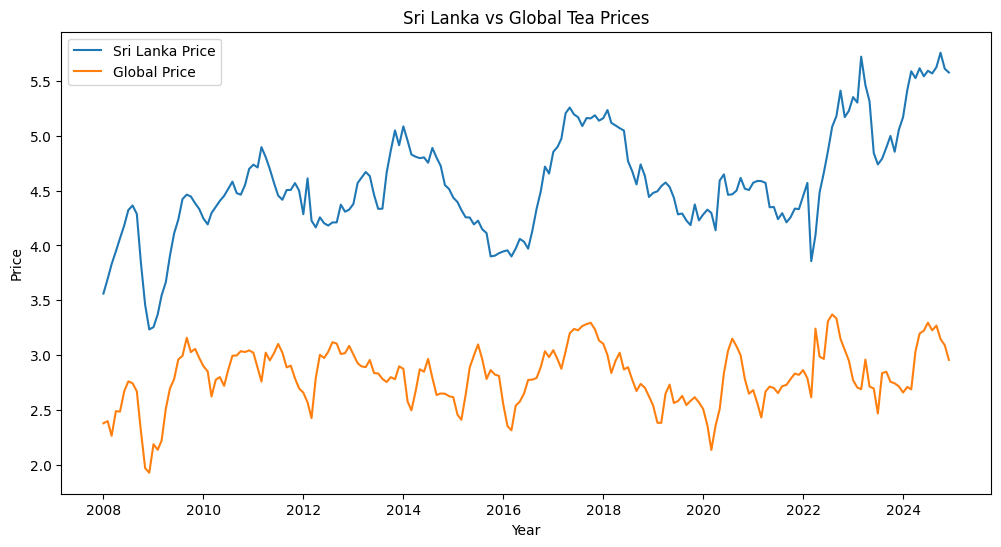

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Export Price (USD/kg)'], label='Sri Lanka Price')
plt.plot(df.index, df['Global_Tea_Price ($)'], label='Global Price')

plt.title("Sri Lanka vs Global Tea Prices")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend()
plt.show()

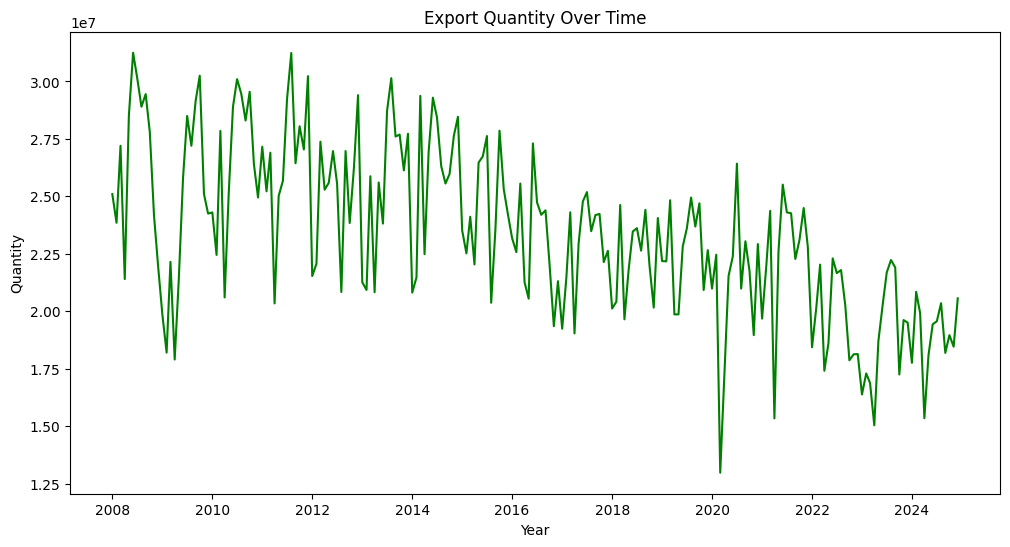

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Export Quantity (kg)'], color='green')

plt.title("Export Quantity Over Time")
plt.xlabel("Year")
plt.ylabel("Quantity")
plt.show()

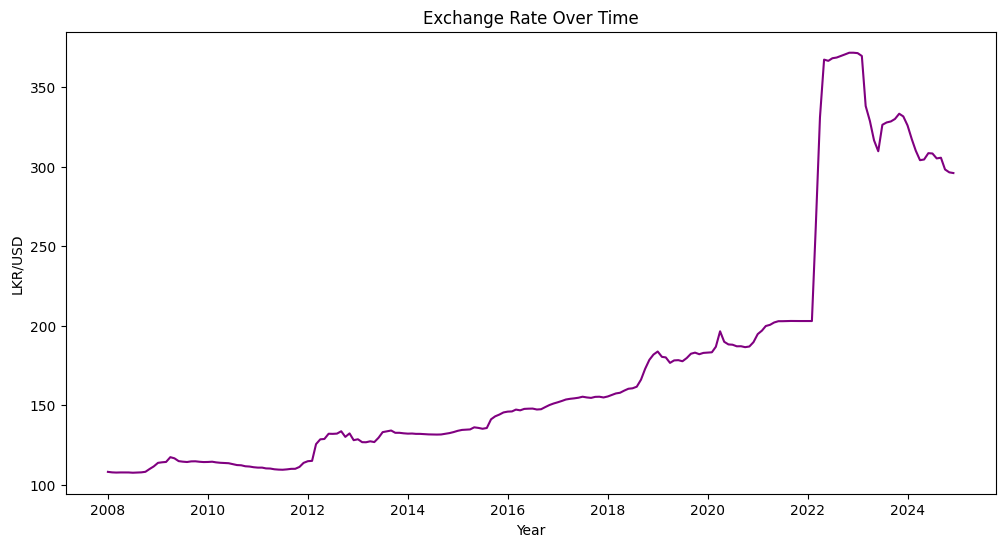

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Exchange Rate (LKR/USD)'], color='purple')

plt.title("Exchange Rate Over Time")
plt.xlabel("Year")
plt.ylabel("LKR/USD")
plt.show()

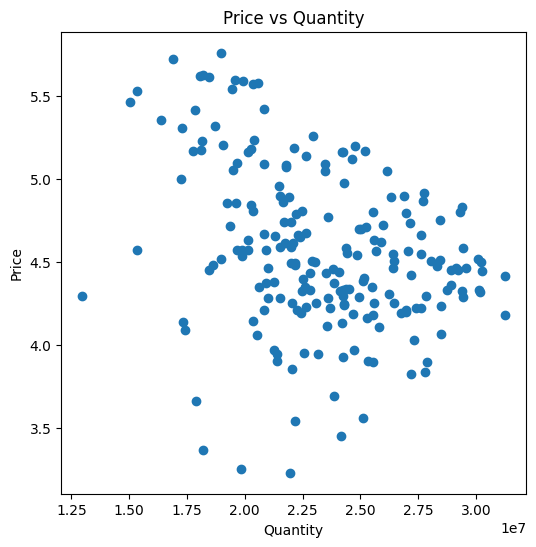

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(df['Export Quantity (kg)'], df['Export Price (USD/kg)'])

plt.xlabel("Quantity")
plt.ylabel("Price")
plt.title("Price vs Quantity")
plt.show()

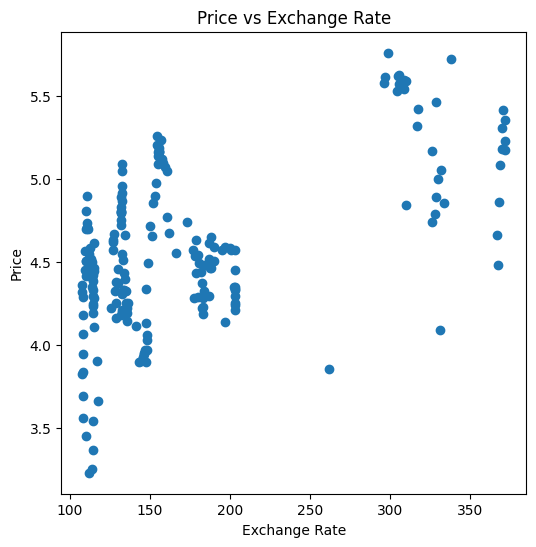

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(df['Exchange Rate (LKR/USD)'], df['Export Price (USD/kg)'])

plt.xlabel("Exchange Rate")
plt.ylabel("Price")
plt.title("Price vs Exchange Rate")
plt.show()

START (Log Returns)

In [ ]:
import numpy as np

df['Log_Return'] = np.log(
    df['Export Price (USD/kg)'] / df['Export Price (USD/kg)'].shift(1)
)

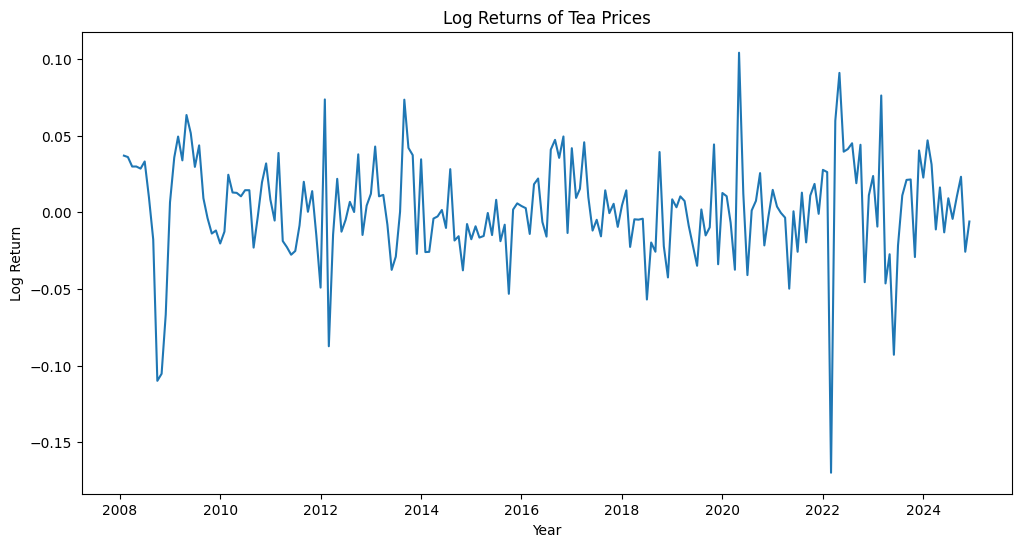

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df.index, df['Log_Return'])

plt.title("Log Returns of Tea Prices")
plt.xlabel("Year")
plt.ylabel("Log Return")
plt.show()

In [ ]:
returns = df['Log_Return'].dropna()

Stationarity Test (ADF)

In [ ]:
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(returns)

print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])

for key, value in adf_test[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Statistic: -12.01583782867413
p-value: 3.1039831383380927e-22
Critical Value (1%): -3.4631437906252636
Critical Value (5%): -2.8759570379821047
Critical Value (10%): -2.574454682874228


ACF & PACF (MODEL IDENTIFICATION)

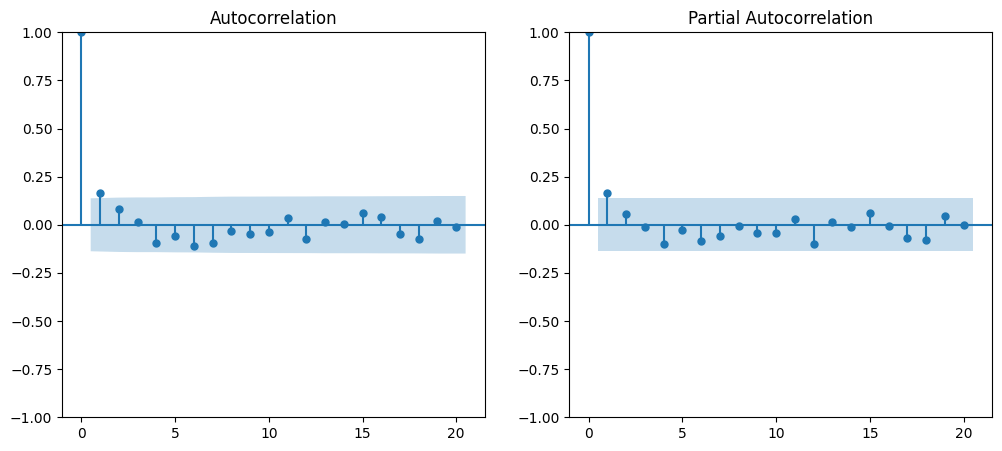

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(returns, lags=20, ax=plt.gca())

plt.subplot(1,2,2)
plot_pacf(returns, lags=20, ax=plt.gca())

plt.show()

Fit ARIMA Models (PROPERLY)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Model 1: ARIMA(1,0,1)
model_101 = ARIMA(returns, order=(1,0,1)).fit()

# Model 2: ARIMA(1,0,0)
model_100 = ARIMA(returns, order=(1,0,0)).fit()

# Model 3: ARIMA(0,0,1)
model_001 = ARIMA(returns, order=(0,0,1)).fit()

print("ARIMA(1,0,1) AIC:", model_101.aic)
print("ARIMA(1,0,0) AIC:", model_100.aic)
print("ARIMA(0,0,1) AIC:", model_001.aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

ARIMA(1,0,1) AIC: -801.8283663432619
ARIMA(1,0,0) AIC: -803.3631614809849
ARIMA(0,0,1) AIC: -802.6978967358971


Model Summary

In [ ]:
print(model_100.summary())

                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                  203
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 404.682
Date:                Wed, 22 Apr 2026   AIC                           -803.363
Time:                        07:14:56   BIC                           -793.424
Sample:                    02-01-2008   HQIC                          -799.342
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0022      0.003      0.757      0.449      -0.004       0.008
ar.L1          0.1640      0.047      3.495      0.000       0.072       0.256
sigma2         0.0011   6.47e-05     16.774      0.0

Residual Visualization

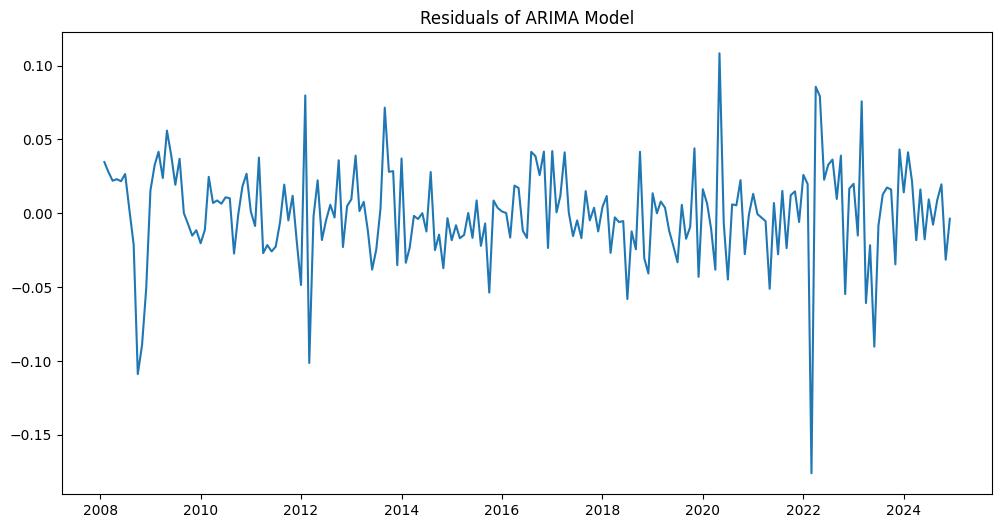

In [ ]:
residuals = model_100.resid

plt.figure(figsize=(12,6))
plt.plot(residuals)

plt.title("Residuals of ARIMA Model")
plt.show()

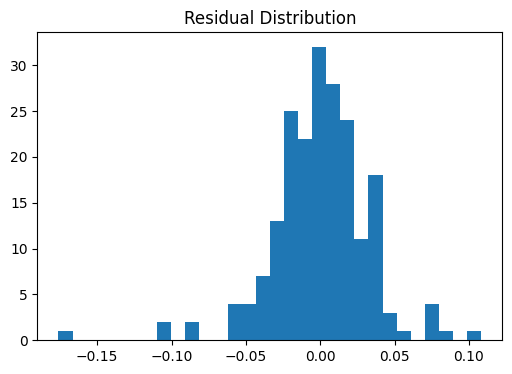

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)

plt.title("Residual Distribution")
plt.show()

FORECASTING

In [ ]:
forecast = model_100.get_forecast(steps=12)

forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

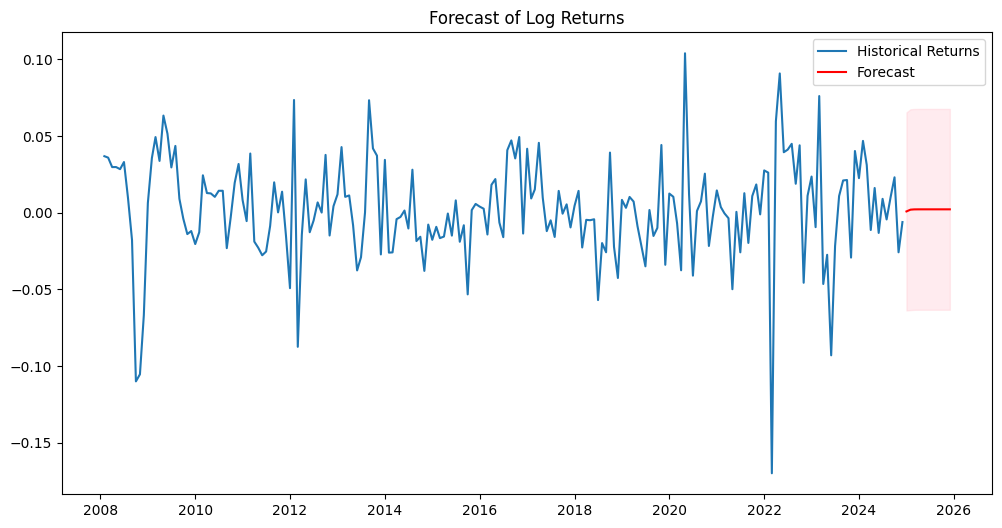

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(returns.index, returns, label='Historical Returns')
plt.plot(forecast_mean.index, forecast_mean, color='red', label='Forecast')

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color='pink',
    alpha=0.3
)

plt.title("Forecast of Log Returns")
plt.legend()
plt.show()

In [ ]:
last_price = df['Export Price (USD/kg)'].iloc[-1]

price_forecast = [last_price]

for r in forecast_mean:
    next_price = price_forecast[-1] * np.exp(r)
    price_forecast.append(next_price)

price_forecast = price_forecast[1:]

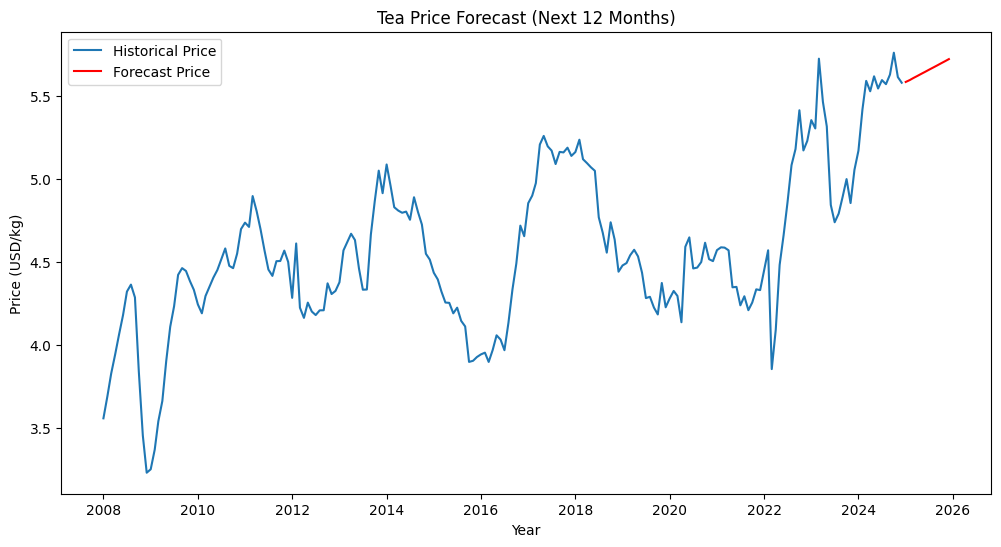

In [ ]:
forecast_index = forecast_mean.index

plt.figure(figsize=(12,6))

plt.plot(df.index, df['Export Price (USD/kg)'], label='Historical Price')
plt.plot(forecast_index, price_forecast, color='red', label='Forecast Price')

plt.title("Tea Price Forecast (Next 12 Months)")
plt.xlabel("Year")
plt.ylabel("Price (USD/kg)")
plt.legend()
plt.show()

VALIDATION METRICS

In [ ]:
train_size = int(len(returns) * 0.8)

train = returns[:train_size]
test = returns[train_size:]

In [ ]:
model_train = ARIMA(train, order=(1,0,0)).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
forecast_test = model_train.get_forecast(steps=len(test))
predicted = forecast_test.predicted_mean

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, predicted)
rmse = np.sqrt(mean_squared_error(test, predicted))
mape = np.mean(np.abs((test - predicted) / test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 0.0320941997002781
RMSE: 0.04420396601586071
MAPE: 102.87675717035161


INTERVAL FORECAST

In [ ]:
# Get forecast results
forecast = model_100.get_forecast(steps=12)

# Mean forecast (returns)
forecast_mean = forecast.predicted_mean

# Confidence intervals
conf_int = forecast.conf_int()

# Extract lower and upper bounds
lower_bound = conf_int.iloc[:, 0]
upper_bound = conf_int.iloc[:, 1]

In [ ]:
price_lower = []
price_upper = []

for i in range(len(forecast_mean)):
    lower = price_forecast[i] * np.exp(lower_bound.iloc[i])
    upper = price_forecast[i] * np.exp(upper_bound.iloc[i])

    price_lower.append(lower)
    price_upper.append(upper)

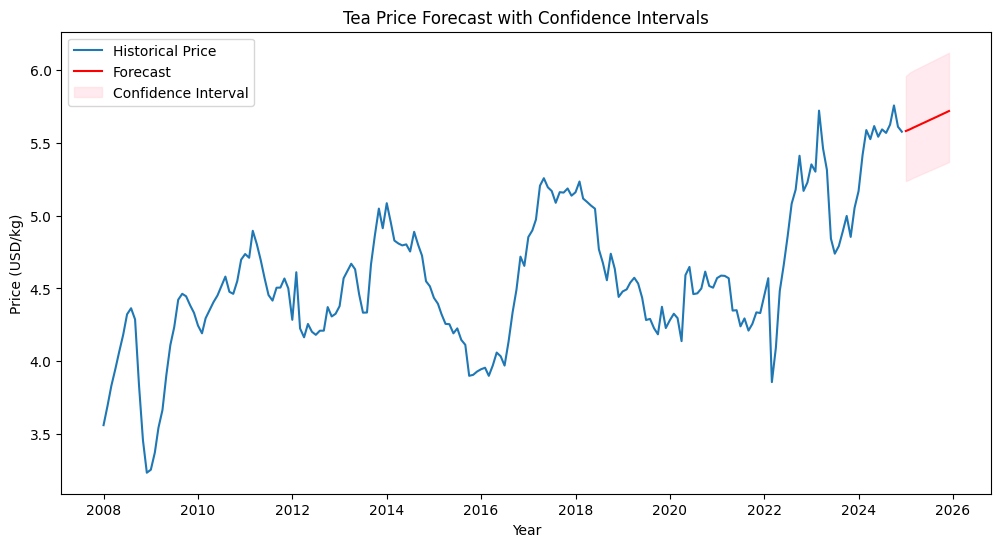

In [ ]:
plt.figure(figsize=(12,6))

# Historical data
plt.plot(df.index, df['Export Price (USD/kg)'], label='Historical Price')

# Forecast line
plt.plot(forecast_index, price_forecast, color='red', label='Forecast')

# Confidence interval (corrected)
plt.fill_between(
    forecast_index,
    price_lower,
    price_upper,
    color='pink',
    alpha=0.3,
    label='Confidence Interval'
)

plt.title("Tea Price Forecast with Confidence Intervals")
plt.xlabel("Year")
plt.ylabel("Price (USD/kg)")
plt.legend()
plt.show()